In [1]:
import pandas as pd

In [3]:
# 데이터 특성에 맞는 차트 선택 방법 학습.
# 기본차트 : 선, 막대, 산점도, 히스토그램, 파이차트
# 차트 스타일링 : 색상, 선, 마커, 
# 제목, 축, 레이블, 범례, 격자


In [4]:
# Matplotlib 라이브러리

In [7]:
# 데이터 시각화 : 사람용.

# [10,12,15,13,18,25,30,28,35,42]
# 숫자로는 증가인지 감소인지 파악하는게  사람은 힘들다.
# 라인 그래프를 그리면 한눈에 보인다.

In [8]:
# 의사결정 속도 향상

In [9]:
# 시간에 따른 변화 -> 선 그래프
# 항목간에 비교 하고 싶을때 -> 막대 그래프
# 상관관계 분석 -> 히트맵
# 데이터 분포를 파악 -> 히스토그램
# 비율 -> 파이 차트 

In [10]:
# 시계열 -> 선그래프
# 범주용 데이터 -> 막대 그래프
# 두 변수의 관계 -> 산점도
# 분포 -> 히스토 그램
# 구성 -> 파이차트

In [11]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [39]:

from koreanize_matplotlib import koreanize
koreanize()

In [13]:
equipment_df = pd.read_csv('./data/01_equipment.csv')
production_df=pd.read_csv('./data/05_production.csv', parse_dates= ['production_date'])

In [14]:
production_df['불량률']=(production_df['defect_quantity']/production_df['actual_quantity']*100).round(2)

In [15]:
# 일별 생산량 집계

In [18]:
daily_production=production_df.groupby('production_date')['actual_quantity'].sum()

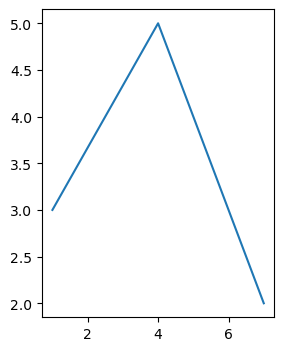

In [27]:
# 라인 그리는 차트 -> 선그래프
# (1,3),(4,5),(7,2)
# x : [1,4,7]
# y : [3,5,2]
plt.figure(figsize= (3,4)) # 비율 을 맞춰주는 함수
plt.plot([1,4,7],[3,5,2])
plt.show() # 차트만 보여주는 함수


In [30]:
daily_production.index # x축에 넣을 데이터

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-12',
               '2024-01-13', '2024-01-14', '2024-01-15', '2024-01-16',
               '2024-01-17', '2024-01-18', '2024-01-19', '2024-01-20',
               '2024-01-21', '2024-01-22', '2024-01-23', '2024-01-24',
               '2024-01-25', '2024-01-26', '2024-01-27', '2024-01-28',
               '2024-01-29', '2024-01-30', '2024-01-31', '2024-02-01',
               '2024-02-02', '2024-02-03', '2024-02-04', '2024-02-05',
               '2024-02-06', '2024-02-07', '2024-02-08', '2024-02-09',
               '2024-02-10', '2024-02-11', '2024-02-12', '2024-02-13',
               '2024-02-14', '2024-02-15', '2024-02-16', '2024-02-17',
               '2024-02-18', '2024-02-19', '2024-02-20', '2024-02-21',
               '2024-02-22', '2024-02-23', '2024-02-24', '2024-02-25',
      

In [32]:
daily_production.values # y축

array([2019, 2380, 1848, 2358, 2330, 2503, 2831, 2471, 2210, 2491, 2254,
       2376, 2325, 2168, 1960, 2513, 1813, 2496, 2515, 1722, 2282, 1996,
       2415, 2135, 2318, 1939, 1825, 2295, 2071, 2561, 2429, 2041, 2440,
       2443, 1861, 2684, 2482, 2019, 1951, 2096, 2059, 2423, 2080, 2277,
       2541, 2330, 2528, 2065, 2222, 2162, 2433, 2955, 2374, 2227, 2242,
       2169, 2292, 2219, 2609, 2166, 2111, 2781, 2442, 2285, 2472, 2697,
       2338, 1876, 2433, 2278, 2309, 2045, 2420, 2531, 2148, 2297, 2149,
       2335, 2061, 2120, 2440, 1946, 2368, 2117, 1897, 2132, 2496, 2107,
       2551, 2050, 2133])

In [60]:
daily_production.shift(1)

production_date
2024-01-01       NaN
2024-01-02    2019.0
2024-01-03    2380.0
2024-01-04    1848.0
2024-01-05    2358.0
               ...  
2024-03-27    2132.0
2024-03-28    2496.0
2024-03-29    2107.0
2024-03-30    2551.0
2024-03-31    2050.0
Name: actual_quantity, Length: 91, dtype: float64

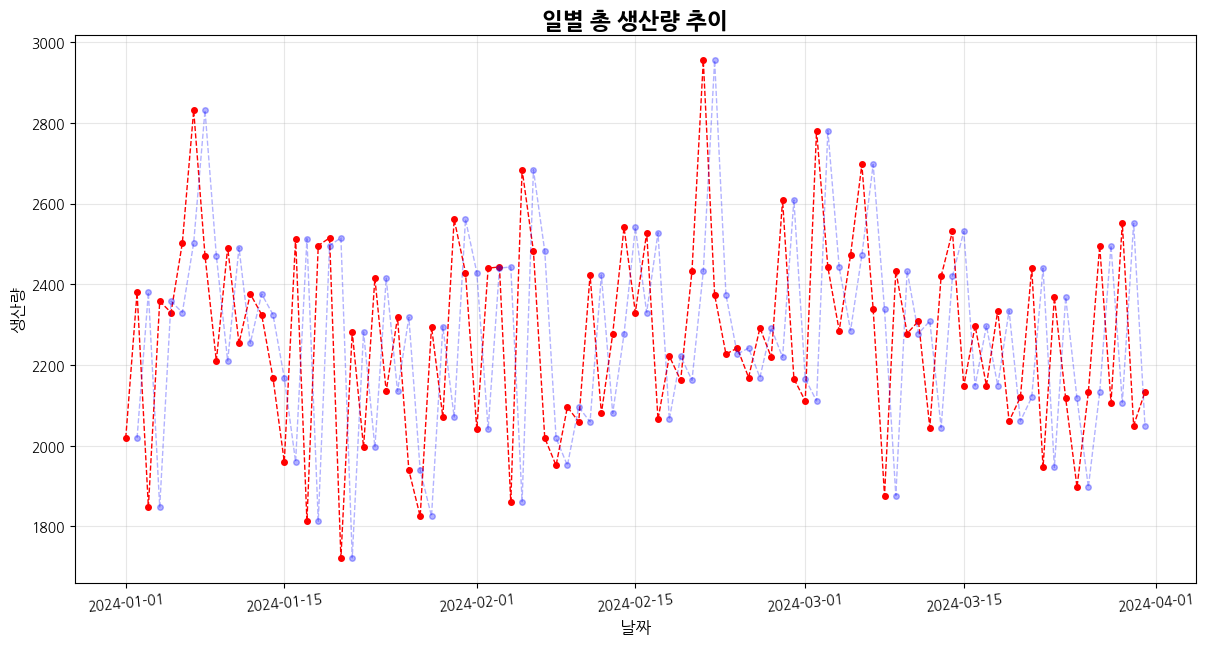

In [72]:

plt.figure(figsize=(12,6))

#색깔, 마커, 라인
plt.plot(daily_production.index,daily_production.values, color = 'red',linewidth =1, marker='o',markersize=4, linestyle='--')
plt.plot(daily_production.shift().index,daily_production.shift().values, color = 'blue',linewidth =1, marker='o',markersize=4, linestyle='--',alpha=0.3)

plt.grid(True,alpha=0.3) # 격자

#레이아웃_자동조절
plt.tight_layout()

plt.title('일별 총 생산량 추이',fontsize=16,fontweight='bold')# 제목

plt.xlabel('날짜',fontsize= 12) # 라벨 작성
plt.ylabel('생산량',fontsize= 12)
plt.xticks(rotation=6) 

plt.savefig('chart01.jpg')
plt.show()

In [62]:
#설비별  총 생산량

In [70]:
equip_df=production_df.groupby('equipment_id')['actual_quantity'].sum().sort_values(ascending=False)

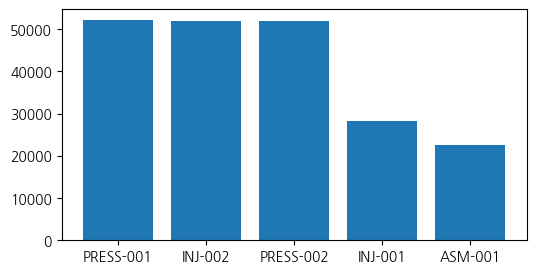

In [71]:
# 막대 그래프 (bar chart)
plt.figure(figsize=(6,3))
plt.bar(equip_df.index,equip_df.values)
plt.show()


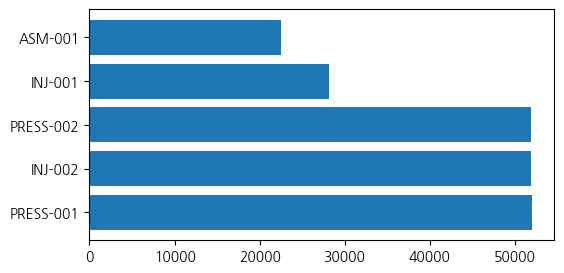

In [73]:

plt.figure(figsize=(6,3))
plt.barh(equip_df.index,equip_df.values) # 가로 막대
plt.show()


In [76]:
# Sctter plot 산점도
# 두 변수간의 상관 관계 분석할 때 사용
# Outlier 발견할 때.
# 패턴, 군집(clustering) 을 발견
# 컬럼 두개인 것을 넣어야 함

In [75]:
#생산량 vs 불량개수

In [77]:
production_df['actual_quantity']

0        81
1        78
2       135
3        92
4       129
       ... 
1867    144
1868    130
1869     80
1870    121
1871     90
Name: actual_quantity, Length: 1872, dtype: int64

In [78]:
production_df['defect_quantity']

0        4
1        6
2        3
3        2
4        7
        ..
1867    25
1868    21
1869    14
1870    20
1871    16
Name: defect_quantity, Length: 1872, dtype: int64

In [90]:
production_df[['actual_quantity','defect_quantity']].corr() # 상관 관계를 볼때 보는 표

,actual_quantity,defect_quantity
actual_quantity,1.000000,0.259056
defect_quantity,0.259056,1.000000


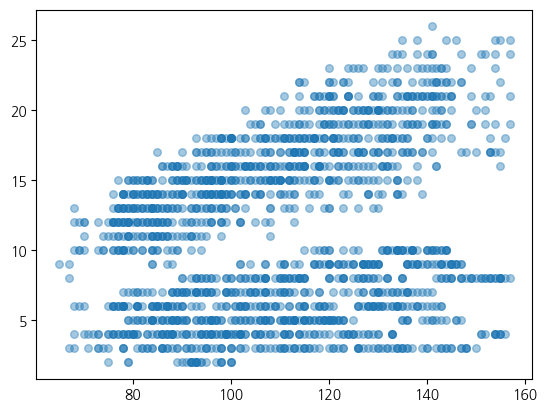

In [91]:
plt.scatter(production_df['actual_quantity'],production_df['defect_quantity'],s=30,alpha=0.4)
plt.show()
# 스캐터이용할때는 상관계수표를 함께 제출

In [93]:
#히스토그램

In [ ]:
# 구간을 잡고, 해당 구간의 데이터의 수를 표시하는 것 -> 분포를 알 수 있다.

In [95]:
# 편향 : 좌우 대칭인가?

In [108]:
#불량률 분포
production_df['불량률'].describe()
my_bins=np.arange(2,20+2,0.1)

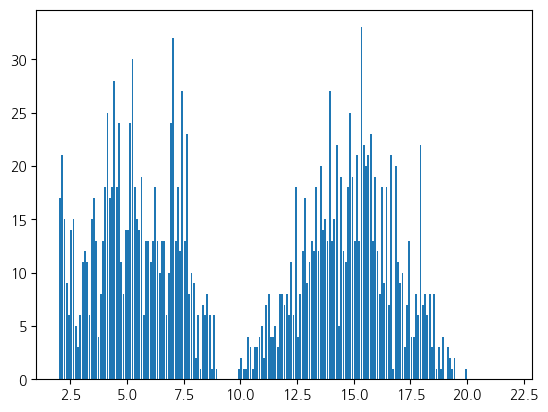

In [109]:
# 히스토그램의 bins를 조절할 수 있는 게 장점
# 갯수로 조정하려면 bins =20 -> 20개
# 범위로 조정하려면 binㄴ= [10,15,20,25,30] -> 최솟값 10, 최대값 30, 간격 5 


plt.hist(production_df['불량률'],rwidth=0.8,bins=my_bins)
plt.show()

In [131]:
#파이 차트 <----교대조 별로 생산건수

In [118]:
shift_df=production_df.groupby('shift')['actual_quantity'].sum()

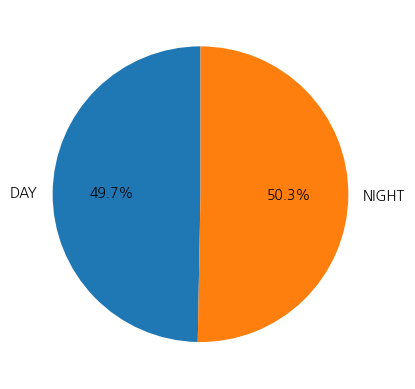

In [123]:
plt.pie(shift_df, labels = shift_df.index, startangle =90, autopct='%.1f%%')
plt.show()

In [126]:
eq_df=production_df.groupby('equipment_id')['불량률'].mean()

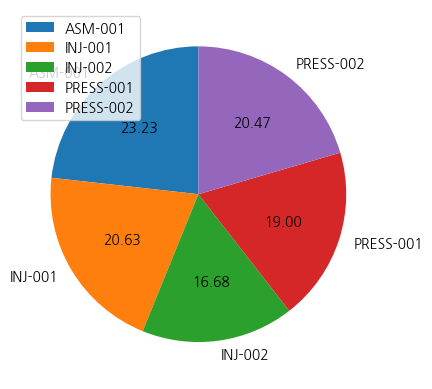

In [ ]:
plt.pie(eq_df,labels= eq_df.index, startangle=90, autopct='%.2f')
plt.legend() #각 정보 디스플레이, 위치 변경도 가능 
plt.show()